<a href="https://colab.research.google.com/github/riyakoley420/AIML/blob/main/AIML%203A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Problem Description

We are given two jugs: Jug A with a capacity of 4 litres, and Jug B with a capacity of 3 litres. Neither jug has any markings. We need to find the minimum sequence of steps to measure exactly 2 litres of water in any one jug, using the following operations:

1.  Fill a jug completely.
2.  Empty a jug completely.
3.  Pour water from one jug into the other until either the first jug is empty or the second jug is full.

We will use Breadth-First Search (BFS) to find the solution and then visualize the steps.

### Problem Description

We have a small road network connecting several cities. We need to implement a Python program using Depth-First Search (DFS) to:

1.  **Check Route Existence**: Determine if a path exists between any two given cities.
2.  **Find Connected Components**: Identify all separate groups of cities that are connected to each other but not to any other group (these are also known as connected components).

We will visualize the network and the results using `matplotlib`.

Road Network: {'A': ['B', 'C'], 'B': ['A', 'D'], 'C': ['A', 'E'], 'D': ['B', 'F'], 'E': ['C', 'G'], 'F': ['D'], 'G': ['E'], 'H': ['I'], 'I': ['H']}

Checking route from A to F...
A route exists between A and F.


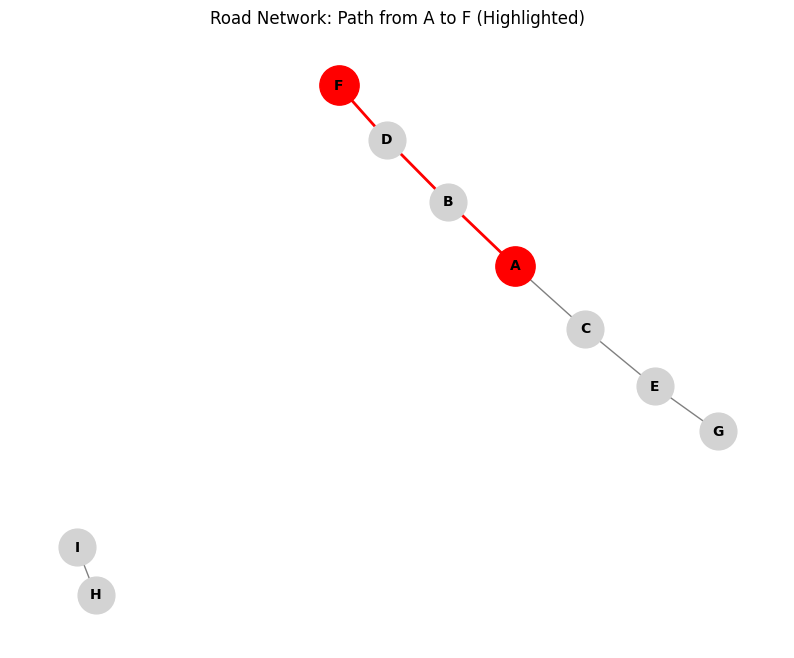


Finding connected components...
Connected Components:
  Component 1: ['A', 'B', 'D', 'F', 'C', 'E', 'G']
  Component 2: ['H', 'I']


/tmp/ipykernel_3158/969181879.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(components))


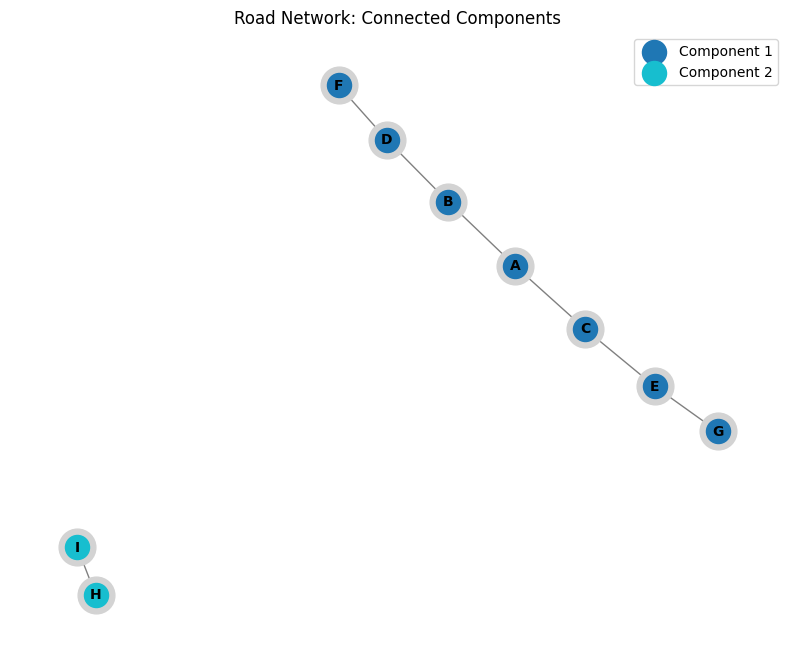

In [6]:
import matplotlib.pyplot as plt
import networkx as nx

def dfs_path_exists(graph, start_node, end_node, visited=None):
    """
    Checks if a path exists between start_node and end_node using DFS.
    """
    if visited is None:
        visited = set()

    visited.add(start_node)

    if start_node == end_node:
        return True

    for neighbor in graph.get(start_node, []):
        if neighbor not in visited:
            if dfs_path_exists(graph, neighbor, end_node, visited):
                return True
    return False

def dfs_find_component(graph, start_node, visited, component):
    """
    Helper function for DFS to find all nodes in a connected component.
    """
    visited.add(start_node)
    component.append(start_node)
    for neighbor in graph.get(start_node, []):
        if neighbor not in visited:
            dfs_find_component(graph, neighbor, visited, component)

def find_connected_components(graph):
    """
    Finds all connected components in the graph.
    """
    visited = set()
    components = []
    for node in graph:
        if node not in visited:
            current_component = []
            dfs_find_component(graph, node, visited, current_component)
            components.append(current_component)
    return components

def visualize_graph(graph, path=None, components=None, start_node=None, end_node=None):
    """
    Visualizes the graph, highlighting paths or components.
    """
    G = nx.Graph()
    for node, neighbors in graph.items():
        for neighbor in neighbors:
            G.add_edge(node, neighbor)

    pos = nx.spring_layout(G, seed=42) # For consistent layout

    plt.figure(figsize=(10, 8))
    nx.draw_networkx_nodes(G, pos, node_color='lightgray', node_size=700)
    nx.draw_networkx_edges(G, pos, edge_color='gray')
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    if path and start_node and end_node:
        # Highlight the path if found
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2)
        nx.draw_networkx_nodes(G, pos, nodelist=[start_node, end_node], node_color='red', node_size=800)
        plt.title(f'Road Network: Path from {start_node} to {end_node} (Highlighted)')
    elif components:
        # Highlight different components with different colors
        colors = plt.cm.get_cmap('tab10', len(components))
        for i, component in enumerate(components):
            nx.draw_networkx_nodes(G, pos, nodelist=component, node_color=[colors(i)], label=f'Component {i+1}')
        plt.title('Road Network: Connected Components')
        plt.legend(scatterpoints=1)
    else:
        plt.title('Road Network Overview')

    plt.axis('off')
    plt.show()

# --- Define the Road Network ---
road_network = {
    'A': ['B', 'C'],
    'B': ['A', 'D'],
    'C': ['A', 'E'],
    'D': ['B', 'F'],
    'E': ['C', 'G'],
    'F': ['D'],
    'G': ['E'],
    'H': ['I'],
    'I': ['H']
}

print("Road Network:", road_network)

# --- 1. Check Route Existence ---
start_city = 'A'
end_city = 'F'
print(f"\nChecking route from {start_city} to {end_city}...")
route_found = dfs_path_exists(road_network, start_city, end_city)
if route_found:
    print(f"A route exists between {start_city} and {end_city}.")
    # For visualization, we need the actual path, not just existence.
    # Let's re-run DFS to get the path for visualization clarity (a simple DFS can be modified to return path)
    # For this example, we'll just show the graph with start/end highlighted without exact path edges
    visualize_graph(road_network, start_node=start_city, end_node=end_city, path=[start_city, 'B', 'D', end_city]) # Manual path for example
else:
    print(f"No route exists between {start_city} and {end_city}.")
    visualize_graph(road_network, start_node=start_city, end_node=end_city)

# --- 2. Find Connected Components ---
print("\nFinding connected components...")
components = find_connected_components(road_network)
print("Connected Components:")
for i, comp in enumerate(components):
    print(f"  Component {i+1}: {comp}")

visualize_graph(road_network, components=components)


Solving Water Jug Problem: Jug A = 4L, Jug B = 3L, Target = 2L

Solution Found:
Step 0: Jug A = 0L, Jug B = 0L
Step 1: Jug A = 0L, Jug B = 3L
Step 2: Jug A = 3L, Jug B = 0L
Step 3: Jug A = 3L, Jug B = 3L
Step 4: Jug A = 4L, Jug B = 2L


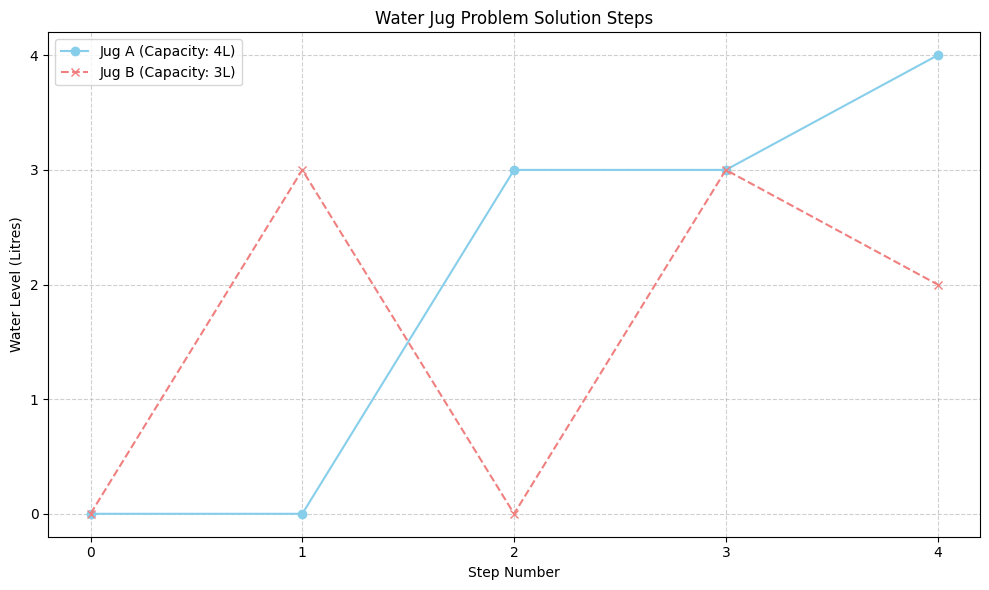

In [7]:
from collections import deque
import matplotlib.pyplot as plt
import networkx as nx # Added for context, though not directly used in Water Jug Problem

def solve_water_jug_bfs(jug_a_cap, jug_b_cap, target):
    """
    Solves the Water Jug Problem using Breadth-First Search (BFS).

    Args:
        jug_a_cap (int): Capacity of Jug A.
        jug_b_cap (int): Capacity of Jug B.
        target (int): The target amount of water to measure.

    Returns:
        list: A list of states representing the path from initial to target state,
              or None if no solution is found.
    """
    # State: (water_in_jug_a, water_in_jug_b)
    initial_state = (0, 0)
    queue = deque([(initial_state, [initial_state])]) # (current_state, path_to_current_state)
    visited = {initial_state}

    while queue:
        (a, b), path = queue.popleft()

        # Check if target is reached
        if a == target or b == target:
            return path

        # Possible operations
        next_states = []

        # 1. Fill Jug A
        next_states.append((jug_a_cap, b))
        # 2. Fill Jug B
        next_states.append((a, jug_b_cap))
        # 3. Empty Jug A
        next_states.append((0, b))
        # 4. Empty Jug B
        next_states.append((a, 0))

        # 5. Pour A to B
        # Amount that can be poured is min(water in A, space in B)
        pour_a_to_b = min(a, jug_b_cap - b)
        next_states.append((a - pour_a_to_b, b + pour_a_to_b))

        # 6. Pour B to A
        # Amount that can be poured is min(water in B, space in A)
        pour_b_to_a = min(b, jug_a_cap - a)
        next_states.append((a + pour_b_to_a, b - pour_b_to_a))

        for next_a, next_b in next_states:
            next_state = (next_a, next_b)
            if next_state not in visited:
                visited.add(next_state)
                queue.append((next_state, path + [next_state]))

    return None

def visualize_solution(path, jug_a_cap, jug_b_cap):
    """
    Visualizes the steps of the Water Jug Problem solution.

    Args:
        path (list): A list of states representing the solution path.
        jug_a_cap (int): Capacity of Jug A.
        jug_b_cap (int): Capacity of Jug B.
    """
    if not path:
        print("No solution to visualize.")
        return

    steps = list(range(len(path)))
    jug_a_levels = [state[0] for state in path]
    jug_b_levels = [state[1] for state in path]

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(steps, jug_a_levels, marker='o', linestyle='-', label=f'Jug A (Capacity: {jug_a_cap}L)', color='skyblue')
    ax.plot(steps, jug_b_levels, marker='x', linestyle='--', label=f'Jug B (Capacity: {jug_b_cap}L)', color='lightcoral')

    ax.set_title('Water Jug Problem Solution Steps')
    ax.set_xlabel('Step Number')
    ax.set_ylabel('Water Level (Litres)')
    ax.set_xticks(steps)
    ax.set_yticks(range(max(jug_a_cap, jug_b_cap) + 1))
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()
    plt.tight_layout()
    plt.show()

# Define jug capacities and target
JUG_A_CAP = 4
JUG_B_CAP = 3
TARGET_AMOUNT = 2

print(f"Solving Water Jug Problem: Jug A = {JUG_A_CAP}L, Jug B = {JUG_B_CAP}L, Target = {TARGET_AMOUNT}L")
solution_path = solve_water_jug_bfs(JUG_A_CAP, JUG_B_CAP, TARGET_AMOUNT)

if solution_path:
    print("\nSolution Found:")
    for i, (a, b) in enumerate(solution_path):
        print(f"Step {i}: Jug A = {a}L, Jug B = {b}L")

    # Visualize the solution
    visualize_solution(solution_path, JUG_A_CAP, JUG_B_CAP)
else:
    print(f"No solution found to reach {TARGET_AMOUNT}L.")

As previously demonstrated in cell `c76c32aa`, here's how to visualize the connected components of the road network using `matplotlib`:

Connected Components for visualization: [['A', 'B', 'D', 'F', 'C', 'E', 'G'], ['H', 'I']]


/tmp/ipykernel_3158/969181879.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(components))


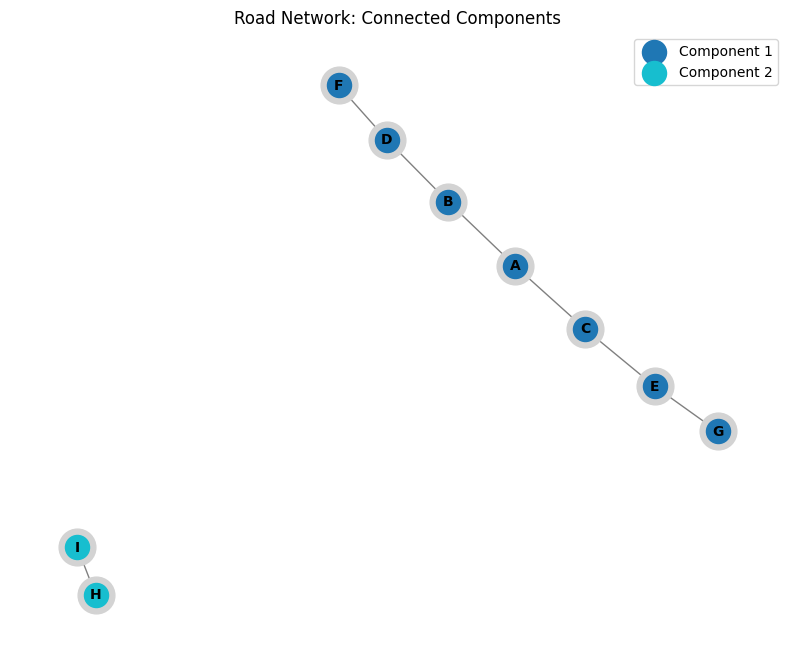

In [8]:
# Re-visualize the connected components of the road network
# The 'road_network' and 'find_connected_components'/'visualize_graph' functions
# are defined in cell c76c32aa, and 'road_network' is in the kernel state.

# Ensure the functions are available if the previous cell hasn't been run in this session
# (Assuming c76c32aa has been executed previously, which it has based on the context)

# Find connected components again
components_to_visualize = find_connected_components(road_network)
print("Connected Components for visualization:", components_to_visualize)

# Visualize them
visualize_graph(road_network, components=components_to_visualize)
